In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect("customer_churn.db")

sql_query = ''' 
        SELECT name
        FROM sqlite_master
        WHERE type = "table"
     '''
tables=pd.read_sql(sql_query,conn)

for table_name in tables["name"]:
    df=pd.read_sql(f"SELECT *FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name' ]:
    print(f"\nTable Name: {table_name}")
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name' ].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


**CUSTOMER TABLE CLEANING**

In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
df_db_customer.describe()

,customerid,name,country,state,gender,dob,interests,pincode
count,21,21,18,21,21,21,4,0
unique,21,21,2,9,4,21,4,0
top,0002-ORFBO,keshav,India,Delhi,Female,1982-04-12 00:00:00,travel,NaN
freq,1,1,17,4,9,1,1,NaN


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
df_db_customer.rename(columns = {"name":"customer_name"})
df_db_customer=df_db_customer.drop(columns=["interests","pincode"],axis=1)

In [8]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [9]:
df_db_customer["dob"]=pd.to_datetime(df_db_customer["dob"])

In [10]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [11]:
df_db_customer["gender"].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [12]:
df_db_customer["gender"] = df_db_customer["gender"].replace({"Men":"Male" , "Women":"Female"})

In [13]:
df_db_customer[df_db_customer["country"].isna()]

,customerid,name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [14]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country' ]. fillna(df_db_customer['state' ].map(state_country_mapping))

In [15]:
df_db_customer

,customerid,name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


**SUBSCRIPTION TABLE CLEANING**

In [16]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [17]:
df_db_subscription.describe()

,monthly_charges,cltv,churn_score
count,21.000000,21.000000,21.000000
mean,18.847143,823.523810,43.285714
std,17.754677,668.913195,32.292635
min,6.990000,42.000000,3.000000
25%,12.990000,240.000000,14.000000
50%,13.990000,640.000000,34.000000
75%,20.990000,1150.000000,76.000000
max,92.990000,2185.000000,99.000000


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [19]:
df_db_subscription["subscription_start_date"]=pd.to_datetime(df_db_subscription["subscription_start_date"])
df_db_subscription["renewal_date"]=pd.to_datetime(df_db_subscription["renewal_date"])
df_db_subscription["cancellation_date"]=pd.to_datetime(df_db_subscription["cancellation_date"])

**SUPPORT TABLE CLEANING**

In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [21]:
df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,None,None
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,None,None
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,None,None
8,0022-TCJCI,2024-09-14 00:00:00,N,90,None,received refund


In [22]:
df_db_support.describe()

,csat_score
count,9.000000
mean,40.555556
std,31.666667
min,10.000000
25%,20.000000
50%,30.000000
75%,60.000000
max,90.000000


In [23]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [24]:
df_db_support=df_db_support.drop(columns={"col_1","comment"})

In [25]:
df_db_support["complaint_date"]=pd.to_datetime(df_db_support["complaint_date"])

In [26]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


***FEATURE ENGINEERING***

In [27]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [28]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [29]:
df_db_customer["customerid"].size

21

In [30]:
df_db_customer["customerid"].nunique()

21

In [31]:
df_db_subscription["customerid"].size

21

In [32]:
df_db_subscription["customerid"].nunique()

21

In [33]:
df_db_support["customerid"].size

9

In [34]:
df_db_support["customerid"].nunique()

7

In [35]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [36]:
df_db_support["complaint_count"]=df_db_support.groupby("customerid")["customerid"].transform("count")

In [37]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [38]:
df_db_support = df_db_support.sort_values("complaint_date").drop_duplicates("customerid" , keep="last")

In [39]:
df_db_support["customerid"].size

7

In [40]:
df = df_db_subscription.merge(df_db_customer , on = "customerid" , how="left").merge(df_db_support , on = "customerid" , how="left")

In [41]:
df.shape

(21, 21)

In [42]:
df.to_csv("Churn_data.csv",index=False)

***DATA ANALYSIS***

In [43]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [44]:
churn_rate = df["churn_flag"].mean()*100
print(f"Churn Rate = {round(churn_rate,2)}%")

Churn Rate = 28.57%


In [45]:
retention_rate = 100-churn_rate
print(f"Retention Rate = {round(retention_rate,2)}%")

Retention Rate = 71.43%


In [46]:
churn_by_plan = df.groupby("plan_type")["churn_flag"].mean().mul(100).round(2).reset_index(name="churn_rate_pct")
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [47]:
churn_by_subscription = df.groupby("subscription_type")["churn_flag"].mean().mul(100).round(2).reset_index(name="churn_rate_pct")
print(churn_by_subscription)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [48]:
churn_by_state = df.groupby("state")["churn_flag"].mean().mul(100).round(2).reset_index(name="churn_rate_pct")
revenue_loss = df[df["churn_flag"] == 1].groupby("state")["monthly_charges"].sum().reset_index(name="revenue_loss")
churn_by_state = churn_by_state.merge(revenue_loss, on="state", how="left").fillna({"revenue_loss": 0})
print(churn_by_state)

           state  churn_rate_pct  revenue_loss
0          Delhi           25.00         13.99
1      Karnataka          100.00         20.98
2      Kathmandu            0.00          0.00
3    Maharashtra            0.00          0.00
4      Meghalaya           66.67         21.98
5       Nagaland            0.00          0.00
6      Rajasthan            0.00          0.00
7      Telangana           50.00         16.99
8  Uttar Pradesh            0.00          0.00


In [49]:
average_revenue_per_user = df["monthly_charges"].mean()
print(f"Average Revenue Per User = {round(average_revenue_per_user,2)}")

Average Revenue Per User = 18.85


In [50]:
df["tenure_days"] = np.where(
    df["cancellation_date"].notna(), 
    (df["cancellation_date"] - df["subscription_start_date"]).dt.days,
    ((pd.Timestamp.today()) - df["subscription_start_date"]).dt.days)

average_tenure = df["tenure_days"].mean()
print(f"Average User Tenure (Days) = {average_tenure}")

Average User Tenure (Days) = 1493.7142857142858


In [51]:
escalation_rate = (df["escalations"]=="Y").mean()*100
print(f"Escalation Rate = {round(escalation_rate,2)}%")

Escalation Rate = 19.05%


In [52]:
conditions = [
(df['churn_score'] < 50),
(df['churn_score'] >= 50) & (df['churn_score'] < 70),
(df['churn_score' ] >= 70)
]
choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

***VISUALIZATION USING MATPLOTLIB***

In [53]:
df_visual = df.copy()

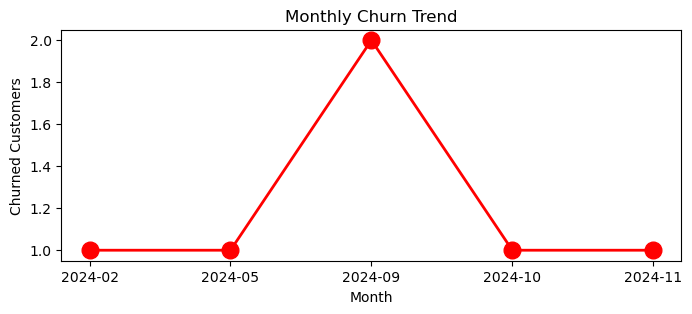

In [54]:
df_visual['cancellation_month' ] = df_visual['cancellation_date' ].dt.to_period( 'M')

churn_trend = df_visual[df_visual['churn_flag' ] == 1].groupby('cancellation_month' ).size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='Red', marker='o', linestyle='solid', linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

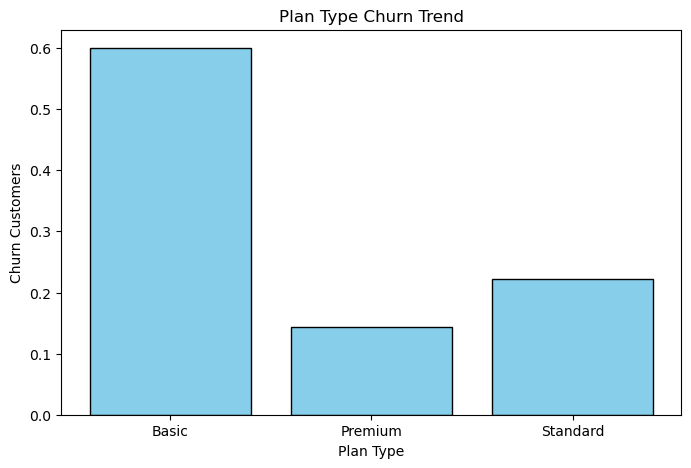

In [55]:
churn_trend = df_visual.groupby('plan_type')["churn_flag"].mean()

plt.figure(figsize=(8, 5))

plt.bar(churn_trend.index, churn_trend.values, color='skyblue', edgecolor='black')

plt.title('Plan Type Churn Trend')
plt.xlabel('Plan Type')
plt.ylabel('Churn Customers')

plt.show()

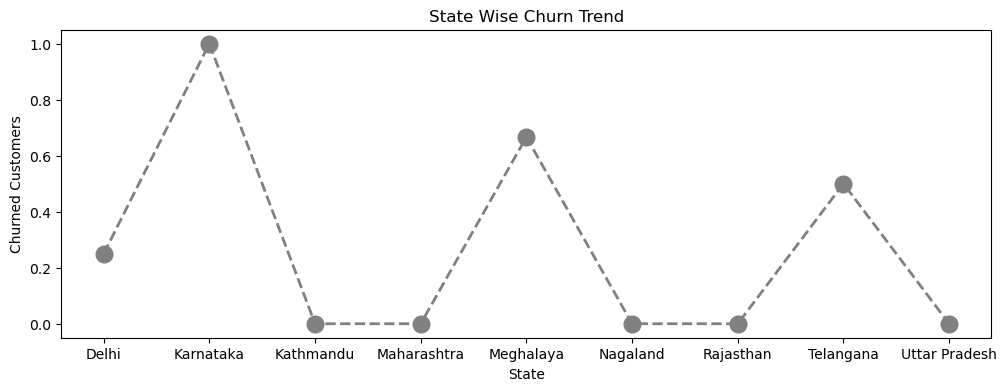

In [56]:
churn_trend = df_visual.groupby('state')["churn_flag"].mean()

plt.figure(figsize=(12,4))

plt.plot(churn_trend.index.astype(str), churn_trend.values, color='Grey', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('State Wise Churn Trend')
plt.xlabel('State')
plt.ylabel('Churned Customers')
plt.show()

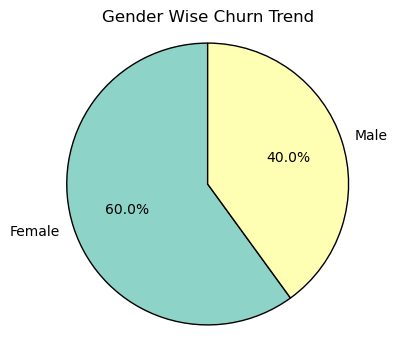

In [57]:
churn_trend = df_visual.groupby('gender')["churn_flag"].mean()

plt.figure(figsize=(4,4))
plt.pie(
    churn_trend.values,
    labels=churn_trend.index,
    autopct='%1.1f%%',
    colors=plt.cm.Set3.colors,
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Gender Wise Churn Trend')
plt.axis('equal')
plt.show()

***VISUALIZATION USING SEABORN***

In [58]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [59]:
df_visual[["plan_type" , "contract_type" , "subscription_type" , "churn_score" , "churn_risk" , "churn_flag" , "escalations"]].head()

,plan_type,contract_type,subscription_type,churn_score,churn_risk,churn_flag,escalations
0,Standard,Annual,Refferal,12,low,0,NaN
1,Premium,Annual,Paid,91,high,1,Y
2,Basic,Monthly,Organic,34,low,0,NaN
3,Premium,Annual,Paid,8,low,0,NaN
4,Standard,Monthly,Refferal,88,high,1,Y


In [60]:
df['escalations'] = df['escalations'].replace({'Y':1 , 'N':2}).fillna(0)

C:\Users\vansh\AppData\Local\Temp\ipykernel_24508\2360659286.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['escalations'] = df['escalations'].replace({'Y':1 , 'N':2}).fillna(0)


In [61]:
df_visual['escalations'] = df_visual['escalations'].replace({'Y':1 , 'N':2}).fillna(0)

C:\Users\vansh\AppData\Local\Temp\ipykernel_24508\4241952764.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_visual['escalations'] = df_visual['escalations'].replace({'Y':1 , 'N':2}).fillna(0)


In [62]:
df_visual[["plan_type" , "contract_type" , "subscription_type" , "churn_score" , "churn_risk" , "churn_flag" , "escalations"]].head()

,plan_type,contract_type,subscription_type,churn_score,churn_risk,churn_flag,escalations
0,Standard,Annual,Refferal,12,low,0,0.0
1,Premium,Annual,Paid,91,high,1,1.0
2,Basic,Monthly,Organic,34,low,0,0.0
3,Premium,Annual,Paid,8,low,0,0.0
4,Standard,Monthly,Refferal,88,high,1,1.0


In [63]:
import warnings
warnings.filterwarnings("ignore") # To Stop Warning after encoding

In [64]:
df_visual["subscription_type"].unique()

array(['Refferal', 'Paid', 'Organic'], dtype=object)

In [65]:
# encoding - based on priority
df_encoded = df_visual[["plan_type" , "contract_type" , "subscription_type" , "churn_score" , "churn_risk" , "churn_flag" , "escalations"]]

order_mappings = {
'plan_type' : ['Basic', 'Standard' , 'Premium'],
'contract_type' : ['Annual' , 'Monthly'],
'churn_risk' : ['low' , 'med' , 'high'],
'subscription_type' : ['Organic' , 'Refferal' , 'Paid']
}

for col , order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category') , categories=order , ordered = True).codes

In [66]:
df_encoded.head()

,plan_type,contract_type,subscription_type,churn_score,churn_risk,churn_flag,escalations
0,1,0,1,12,0,0,0.0
1,2,0,2,91,2,1,1.0
2,0,1,0,34,0,0,0.0
3,2,0,2,8,0,0,0.0
4,1,1,1,88,2,1,1.0


<Axes: >

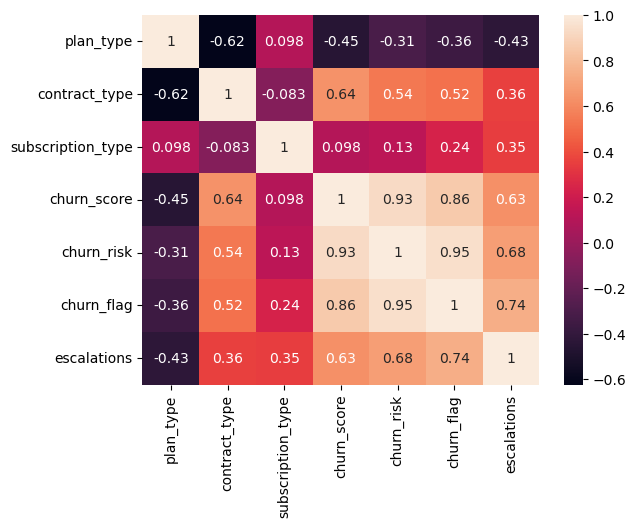

In [67]:
sns.heatmap(df_encoded.corr() , annot=True)

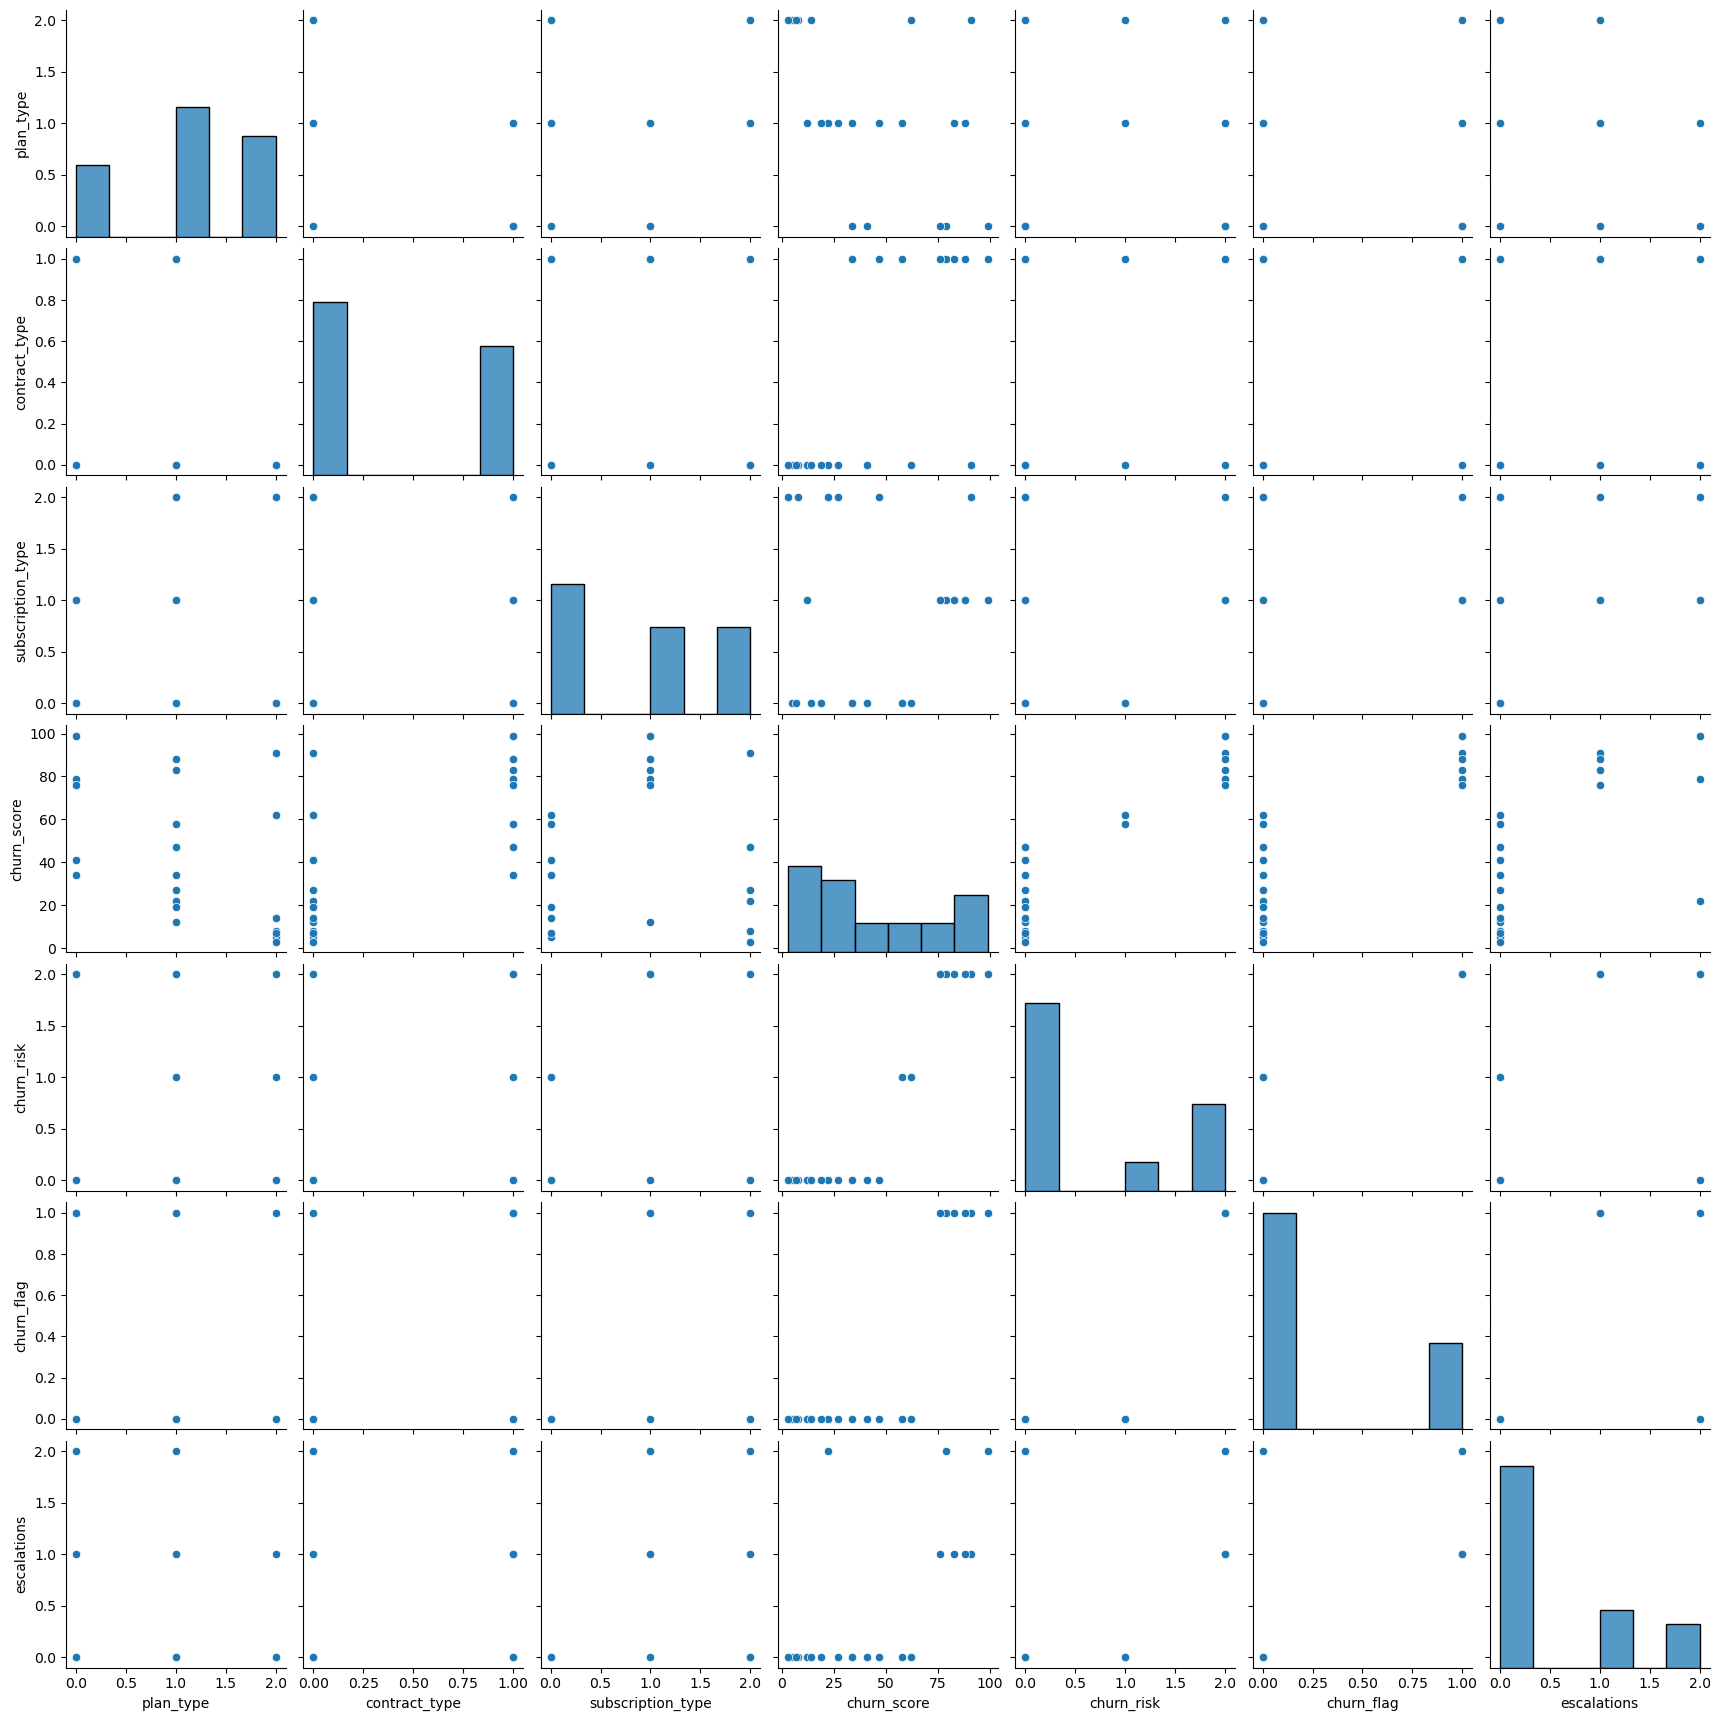

In [68]:
sns.pairplot(df_encoded)

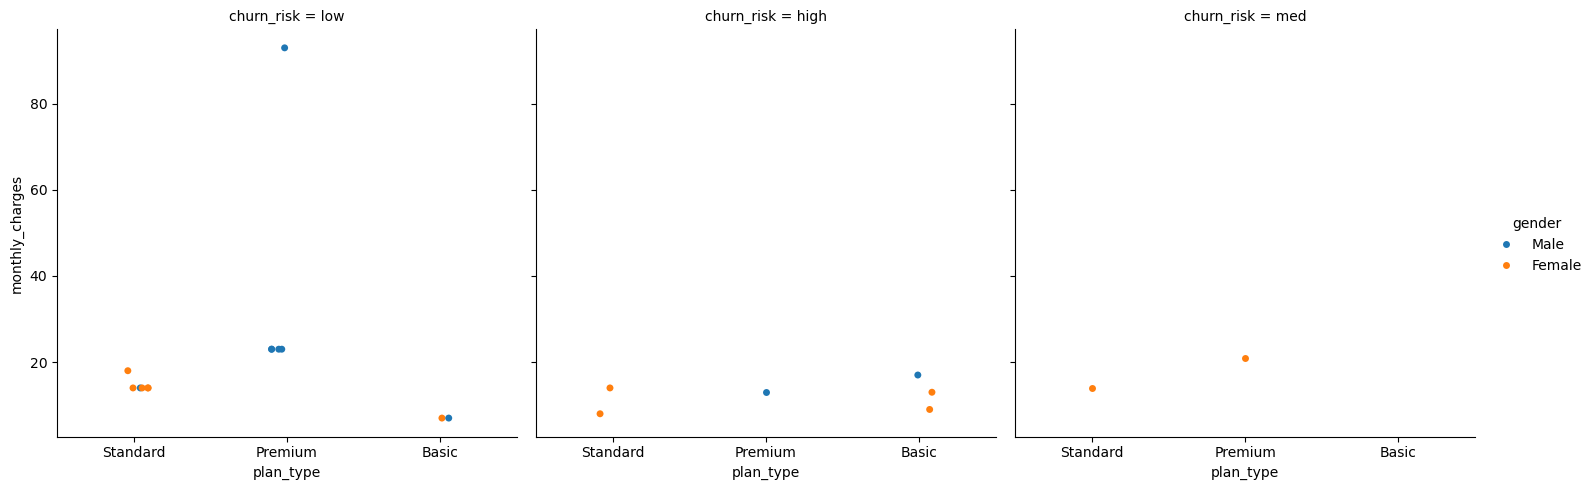

In [79]:
sns.catplot(data=df_visual,
           x="plan_type",
           y="monthly_charges",
           hue="gender",
           #row=,
           col="churn_risk"
           )

***PIVOT TABLE***

In [85]:
pd.pivot_table(df_visual,
              values="churn_flag",
              index="plan_type",
              aggfunc="mean"
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [88]:
pd.pivot_table(
df_visual,
index='plan_type',
values=['monthly_charges', 'customerid', 'churn_flag'],
aggfunc = {
'monthly_charges' : 'sum',
'customerid' : 'nunique',
'churn_flag' : 'mean'
}
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
